In [1]:
# STANDIN A0
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-For-Cybersecurity-Lab-4.2-Robustness-attacks


train 267,984 rows   attack rate 0.1507
val    89,328 rows   attack rate 0.1507
test   89,329 rows   attack rate 0.1507


68 features: 58 continuous, 10 flag columns
Flag columns: Fwd PSH Flags, Fwd URG Flags, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count
  tree    loaded from models/tree.joblib
  logreg  loaded from models/logreg.joblib


  forest  loaded from models/forest.joblib


ATTACK_IDX: 50 detected attacks, forest probability 1.000-1.000
  attack types: {'DDoS': 25, 'DoS Hulk': 22, 'DoS GoldenEye': 2, 'SSH-Patator': 1}
EXPLAIN_IDX: 500 random test flows, 68 of them attacks
Setup complete: 20 shared names ready. The models are scored in step A2.


In [2]:
# STANDIN B1
# Plot styling defined in step B1 (Track 1). Repeated here so this notebook runs on its own.
import matplotlib.pyplot as plt
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"

In [3]:
# STANDIN B1
# --- copy of step B1's add_noise cell (Track 1), so this notebook runs on its own ---
import matplotlib.pyplot as plt

# Columns that are never negative in the training data: clipping these at zero only removes
# impossible values that the noise created (a negative packet count). Columns that are already
# negative in real data (-1 = "not recorded") are left alone, so clipping never edits a real value.
NONNEG_COLS = [c for c in CONT_COLS if X_train[c].min() >= 0]


def add_noise(X, X_ref, level, seed=SEED, clip=True):
    """Noisy copy of X: Gaussian noise of width level * std(X_ref) on every continuous column.

    X_ref must be the training set (std measured there, never on the data being scored).
    The 0/1 flag columns are not touched. With clip=True, columns that are never negative in
    X_ref are clipped at zero after the noise is added.
    """
    noisy = X.copy()
    if level == 0:
        return noisy
    rng = np.random.default_rng(seed)
    std = X_ref[CONT_COLS].std().to_numpy()
    values = noisy[CONT_COLS].to_numpy(dtype=float)
    values += rng.standard_normal(values.shape) * (level * std)
    if clip:
        nonneg = np.isin(CONT_COLS, [c for c in CONT_COLS if X_ref[c].min() >= 0])
        values[:, nonneg] = np.maximum(values[:, nonneg], 0.0)
    noisy[CONT_COLS] = values
    return noisy


# Sanity checks: flags untouched, level 0 changes nothing, clipped columns never negative.
_check = add_noise(X_test.iloc[:1000], X_train, 0.5)
assert _check[FLAG_COLS].equals(X_test.iloc[:1000][FLAG_COLS])
assert add_noise(X_test.iloc[:1000], X_train, 0.0).equals(X_test.iloc[:1000])
assert (_check[NONNEG_COLS] >= 0).all().all()
print(f"{len(NONNEG_COLS)} of {len(CONT_COLS)} continuous columns are clipped at zero")

47 of 58 continuous columns are clipped at zero


In [4]:
# STANDIN B2
# --- copy of step B2's add_missing cell (Track 1), so this notebook runs on its own ---
def add_missing(X, frac, seed=SEED):
    """Copy of X where round(frac * n_features) random features per row are set to TRAIN_MEDIAN."""
    out = X.to_numpy(dtype=float, copy=True)
    k = int(round(frac * X.shape[1]))
    if k > 0:
        rng = np.random.default_rng(seed)
        # k random columns per row: the positions of the k smallest of a row of random numbers.
        cols = np.argpartition(rng.random(out.shape), k - 1, axis=1)[:, :k]
        out[np.arange(len(out))[:, None], cols] = TRAIN_MEDIAN.to_numpy()[cols]
    return pd.DataFrame(out, index=X.index, columns=X.columns)


_check = add_missing(X_test.iloc[:1000], 0.10)
_changed = (_check.to_numpy() != X_test.iloc[:1000].to_numpy())
assert _changed.sum(axis=1).max() <= 7          # at most 7 values per row change (fewer if already = median)
print(f"Per row, {int(round(0.10 * len(FEATURES)))} of {len(FEATURES)} features are replaced "
      f"by the training median ({7 / len(FEATURES):.1%})")

Per row, 7 of 68 features are replaced by the training median (10.3%)


<!-- STEP C1 -->
## Part C: Break the model on purpose

### Step C1: Sort the features and set a budget

An evasion attack is only honest if the attacker changes things a real attacker can change (lab
section 3.4). The attacker sends the **forward** traffic, so they can pad packets and wait longer. They
do not control the victim's replies, and they cannot finish the attack with fewer packets than it
needs. Every feature therefore goes into one of three groups:

| Group | Meaning | Why |
|---|---|---|
| **Free** | timing (inter-arrival times, idle and active timers, flow duration) and forward packet / header / segment sizes | Waiting longer and padding packets cost the attacker almost nothing |
| **Costly** | forward packet and byte counts (`Total Fwd Packets`, `Total Length of Fwd Packets`, forward subflows, forward data packets) | Possible, but every extra packet is more work and makes the attack louder |
| **Fixed** | everything the responder produces (all backward features, its initial window), all flag counts, and every feature we are unsure about | The victim's network stack produces these; the attacker cannot touch them |

The groups are assigned with **name rules in code**, not by hand, in this order: backward or flag →
Fixed; timing → Free; forward sizes → Free; forward counts → Costly; anything else → Fixed. When in
doubt, Fixed: an attack that is weaker than reality is a safer mistake than one that lets the attacker
do the impossible.

Our data has no `Destination Port` or `Protocol` (Lab 1 removed them as ID columns), so those two
Fixed features from the lab text do not appear.

In [5]:
# STEP C1
FREE_SIZES = ["Fwd Header Length", "Avg Fwd Segment Size", "min_seg_size_forward"]
COSTLY_COUNTS = ["Total Fwd Packets", "Total Length of Fwd Packets", "Subflow Fwd Packets",
                 "Subflow Fwd Bytes", "act_data_pkt_fwd"]


def assign_group(name):
    """Free / Costly / Fixed from the feature name, plus the rule that decided it.

    The order matters: the backward check comes first, otherwise 'Bwd IAT Mean' would be Free
    because it contains 'IAT'.
    """
    if "Bwd" in name or "backward" in name.lower():
        return "Fixed", "backward direction: produced by the victim"
    if "Flag" in name:
        return "Fixed", "flag: set by the network stack / responder"
    if any(key in name for key in ("IAT", "Idle", "Active")) or name == "Flow Duration":
        return "Free", "timing: the attacker can wait longer"
    if name.startswith("Fwd Packet Length") or name in FREE_SIZES:
        return "Free", "forward size: the attacker can pad packets"
    if name in COSTLY_COUNTS:
        return "Costly", "forward count: more packets, a louder attack"
    return "Fixed", "unsure (mixes both directions or is derived): Fixed to be safe"


_assigned = {name: assign_group(name) for name in FEATURES}
GROUP = {name: group for name, (group, _) in _assigned.items()}
GROUP_RULE = {name: rule for name, (_, rule) in _assigned.items()}

assert set(GROUP) == set(FEATURES)
counts = pd.Series(GROUP).value_counts().reindex(["Free", "Costly", "Fixed"])
print(counts.to_string())
assert counts.to_dict() == {"Free": 25, "Costly": 5, "Fixed": 38}
for group in ("Free", "Costly", "Fixed"):
    names = [f for f in FEATURES if GROUP[f] == group]
    print(f"\n{group} ({len(names)}):\n  " + ", ".join(names))

Free      25
Costly     5
Fixed     38

Free (25):
  Flow Duration, Fwd Packet Length Max, Fwd Packet Length Min, Fwd Packet Length Mean, Fwd Packet Length Std, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min, Fwd IAT Total, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min, Fwd Header Length, Avg Fwd Segment Size, min_seg_size_forward, Active Mean, Active Std, Active Max, Active Min, Idle Mean, Idle Std, Idle Max, Idle Min

Costly (5):
  Total Fwd Packets, Total Length of Fwd Packets, Subflow Fwd Packets, Subflow Fwd Bytes, act_data_pkt_fwd

Fixed (38):
  Total Backward Packets, Total Length of Bwd Packets, Bwd Packet Length Max, Bwd Packet Length Min, Bwd Packet Length Mean, Bwd Packet Length Std, Flow Bytes/s, Flow Packets/s, Bwd IAT Total, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min, Fwd PSH Flags, Fwd URG Flags, Bwd Header Length, Fwd Packets/s, Bwd Packets/s, Min Packet Length, Max Packet Length, Packet Length Mean, Packet Length Std, Packet Length Variance, FIN

In [6]:
# STEP C1
# The Fixed features that are Fixed only because we were unsure, with the reason.
unsure = [f for f in FEATURES if GROUP_RULE[f].startswith("unsure")]
print(f"{len(unsure)} features are Fixed by the 'when unsure, Fixed' rule:")
for f in unsure:
    print(f"  {f}")

11 features are Fixed by the 'when unsure, Fixed' rule:
  Flow Bytes/s
  Flow Packets/s
  Fwd Packets/s
  Min Packet Length
  Max Packet Length
  Packet Length Mean
  Packet Length Std
  Packet Length Variance
  Down/Up Ratio
  Average Packet Size
  Init_Win_bytes_forward


<!-- STEP C1 -->
**Why the "unsure" features are Fixed.** They fall in two kinds.

- *Mixed direction*: `Min/Max Packet Length`, `Packet Length Mean/Std/Variance`, `Average Packet Size`
  and `Down/Up Ratio` combine the attacker's packets with the victim's replies. The attacker can move
  only part of them, and not reliably.
- *Derived rates*: `Flow Bytes/s`, `Flow Packets/s` and `Fwd Packets/s` are computed from counts and
  duration. Waiting longer *lowers* them, so the attacker cannot raise them independently.

`Init_Win_bytes_forward` is set by the attacker's own TCP stack and could arguably be Costly. We keep
it Fixed for now; if C2's constrained attack evades nothing, it is the first candidate to move (the lab
allows this, as long as the report says so).

<!-- STEP C1 -->
### The constraint check and the budget

- `can_change(feature, old_value, new_value)` is `True` only when the feature is Free or Costly **and**
  the new value is at least the old one. The attacker can add packets and wait longer, never remove or
  speed up.
- **Budget:** one step raises one feature by at most **half its training standard deviation**, and at
  most **five features** may change in total.

In [7]:
# STEP C1
STEP_SIZE = 0.5 * TRAIN_STD          # pandas Series: the largest single-step increase per feature
MAX_CHANGES = 5                      # at most five different features may change per flow
CHANGEABLE = [f for f in FEATURES if GROUP[f] in ("Free", "Costly")]


def can_change(feature, old_value, new_value):
    """True only if the attacker may move this feature from old_value to new_value."""
    return GROUP[feature] in ("Free", "Costly") and new_value >= old_value


# Tests: no Fixed feature can ever change; nothing can decrease; Free and Costly can increase.
for f in FEATURES:
    if GROUP[f] == "Fixed":
        assert not can_change(f, 0.0, 1.0) and not can_change(f, 5.0, 5.0)
    else:
        assert can_change(f, 0.0, STEP_SIZE[f]) and can_change(f, 3.0, 3.0)
        assert not can_change(f, 1.0, 0.0)
print(f"can_change tests passed: {len(CHANGEABLE)} changeable features, "
      f"{len(FEATURES) - len(CHANGEABLE)} Fixed, none of which can change")

can_change tests passed: 30 changeable features, 38 Fixed, none of which can change


<!-- STEP C1 -->
### What one step means in real units

Part B showed that the standard deviations of our columns are inflated by outliers. The step size is
half a standard deviation, so it is worth seeing what that means for a typical flow before running the
attack: a "small" step can be huge compared with the median.

In [8]:
# STEP C1
def unit(name):
    """Unit of a changeable feature, for reading the table below."""
    if any(key in name for key in ("IAT", "Idle", "Active", "Duration")):
        return "µs"
    if "Length" in name or "Bytes" in name or "Size" in name or "seg_size" in name:
        return "bytes"
    return "packets"


steps = pd.DataFrame({
    "group": [GROUP[f] for f in CHANGEABLE],
    "unit": [unit(f) for f in CHANGEABLE],
    "train_median": TRAIN_MEDIAN[CHANGEABLE],
    "step_size": STEP_SIZE[CHANGEABLE],
}, index=pd.Index(CHANGEABLE, name="feature"))
steps["step_over_median"] = steps["step_size"] / steps["train_median"].abs().replace(0, np.nan)
print(steps.sort_values("step_over_median", ascending=False)
      .to_string(float_format=lambda v: f"{v:,.1f}"))

                              group     unit  train_median    step_size  step_over_median
feature                                                                                  
Fwd IAT Min                    Free       µs           3.0  4,773,842.9       1,591,281.0
Flow IAT Min                   Free       µs           4.0  1,584,409.6         396,102.4
Fwd IAT Total                  Free       µs         710.0 18,396,494.8          25,910.6
Fwd IAT Max                    Free       µs         632.5 13,509,832.8          21,359.4
Fwd IAT Mean                   Free       µs         375.5  5,262,371.2          14,014.3
min_seg_size_forward           Free    bytes          20.0     81,021.8           4,051.1
Fwd Header Length              Free    bytes          64.0     81,388.4           1,271.7
act_data_pkt_fwd             Costly  packets           1.0        344.4             344.4
Flow IAT Std                   Free       µs      17,985.3  4,433,822.0             246.5
Flow Durat

<!-- STEP C1 -->
**What one step means.** The steps are large compared with an ordinary flow, because the standard
deviations are inflated by outliers (B1). Most are still *possible* for a patient attacker: one step
adds 4.8 s to the shortest gap between the attacker's packets (`Fwd IAT Min`), 18 s to the flow
duration, 13 s to the idle timers, or about 360 extra packets (Costly).

Two Free steps are **not physically possible**:

- `min_seg_size_forward` is a header size, between 0 and 60 bytes for every normal flow, but one step
  adds 81,022 bytes. Its std comes almost entirely from a few recording-bug values around −84 million.
- `Fwd Header Length` (total header bytes sent by the attacker) gains 81,388 bytes per step. That
  would take roughly 2,000 extra packets, which is not free.

We keep the lab's budget exactly as written, so the attack follows the lab. In C2 we check which
features the successful evasions actually used; if they rely on these two, the report says so (and C2
can re-run with each new value capped at the training maximum as a sensitivity check). Rows whose
median is 0 (`Idle …`, `Active …`, `Fwd IAT Std`) show no ratio: most flows never go idle, so any
step is "infinitely" larger than the median.

In [9]:
# STEP C1
groups_table = pd.DataFrame({
    "feature": FEATURES,
    "group": [GROUP[f] for f in FEATURES],
    "rule": [GROUP_RULE[f] for f in FEATURES],
    "step_size": [STEP_SIZE[f] if GROUP[f] != "Fixed" else np.nan for f in FEATURES],
    "train_median": TRAIN_MEDIAN[FEATURES].to_numpy(),
})
groups_table.to_csv("results/tables/C1_feature_groups.csv", index=False, float_format="%.4g")
print("Saved results/tables/C1_feature_groups.csv")

Saved results/tables/C1_feature_groups.csv


<!-- STEP C2 -->
### Step C2: Run the attack, twice

**Greedy search.** Start from one attack flow. At each of five steps, try every change the attacker is
allowed to make, ask the forest for the attack probability of all candidates in **one**
`predict_proba` call, and keep the candidate that lowers the probability most. Stop early when no
candidate helps, or as soon as the flow is classified benign (probability below 0.5): at that point
the attacker has won, and more changes would only inflate the "features changed" count.

| Run | Which features | Direction | Step | Steps |
|---|---|---|---|---|
| **Constrained** | the 30 Free and Costly features, each new value checked with `can_change`, at most 5 different features | up only | +½ training std | 5 |
| **Unconstrained** | all 68 features | up or down | ±½ training std | 5 |
| Constrained + cap (check) | as constrained, but no value may exceed that feature's training maximum | up only | +½ std, capped | 5 |

The unconstrained run keeps the same step size and number of steps, so the **only** difference
between the first two runs is the network constraints. The third run answers C1's question: do the
evasions depend on the physically impossible steps (`min_seg_size_forward`, `Fwd Header Length`)?

In [10]:
# STEP C2
FEATURE_POS = {f: j for j, f in enumerate(FEATURES)}
TRAIN_MAX = X_train.max()


def greedy_attack(model, x_row, constrained=True, steps=5, cap=False):
    """Greedy evasion of one flow.

    x_row: one row as a DataFrame (X_test.iloc[[i]]). It is never modified; every candidate is a copy.
    constrained=True:  Free/Costly features only, increases only (can_change), at most MAX_CHANGES
                       different features. constrained=False: any feature, up or down.
    Both use the same step size (STEP_SIZE, half a training std) and the same number of steps, so the
    only difference between them is the network constraints.
    cap=True (constrained only): a new value may not exceed the feature's training maximum.
    Returns p_before, p_after, changed (one feature name per step taken) and x_adv (the edited row).
    """
    current = x_row.to_numpy(dtype=float)[0].copy()
    p_before = p = float(model.predict_proba(x_row)[0, 1])
    changed = []
    for _ in range(steps):
        if p < 0.5:                                   # already classified benign: the attacker stops
            break
        if constrained:
            budget_left = len(set(changed)) < MAX_CHANGES
            moves = [(f, +1) for f in CHANGEABLE if budget_left or f in changed]
        else:
            moves = [(f, sign) for f in FEATURES for sign in (+1, -1)]

        candidates, names = [], []
        for f, sign in moves:
            j = FEATURE_POS[f]
            new = current[j] + sign * STEP_SIZE[f]
            if constrained:
                if cap:
                    new = min(new, TRAIN_MAX[f])
                if new == current[j] or not can_change(f, current[j], new):
                    continue
            candidate = current.copy()
            candidate[j] = new
            candidates.append(candidate)
            names.append(f)
        if not candidates:
            break
        probs = model.predict_proba(pd.DataFrame(candidates, columns=FEATURES))[:, 1]
        best = int(np.argmin(probs))
        if probs[best] >= p:                          # nothing helps: stop early
            break
        current, p = candidates[best], float(probs[best])
        changed.append(names[best])

    x_adv = pd.DataFrame([current], columns=FEATURES, index=x_row.index)
    return {"p_before": p_before, "p_after": p, "changed": changed, "x_adv": x_adv}

In [11]:
# STEP C2
RUNS = {
    "constrained": dict(constrained=True),
    "unconstrained": dict(constrained=False),
    "constrained + cap": dict(constrained=True, cap=True),
}
X_test_before = X_test.copy()                         # to prove the attack never edits X_test

attack_runs, adv_rows = {}, {}
for run, options in RUNS.items():
    start = time.time()
    rows, advs = [], []
    for pos in ATTACK_IDX:
        result = greedy_attack(rf, X_test.iloc[[pos]], **options)
        rows.append({
            "test_position": int(pos),
            "attack_type": type_test.iloc[pos],
            "p_before": result["p_before"],
            "p_after": result["p_after"],
            "evaded": result["p_after"] < 0.5,
            "steps_taken": len(result["changed"]),
            "n_features_changed": len(set(result["changed"])),
            "changed": ";".join(result["changed"]),
        })
        advs.append(result["x_adv"])
    attack_runs[run] = pd.DataFrame(rows)
    adv_rows[run] = pd.concat(advs)
    print(f"{run:<18} done in {time.time() - start:.0f} s")

assert X_test.equals(X_test_before), "the attack modified X_test"
del X_test_before

# Constraint audit: in the constrained runs, every Fixed column is untouched and nothing went down.
original = X_test.iloc[ATTACK_IDX]
for run in ("constrained", "constrained + cap"):
    diff = adv_rows[run].to_numpy() - original.to_numpy(dtype=float)
    fixed = [FEATURE_POS[f] for f in FEATURES if GROUP[f] == "Fixed"]
    assert np.all(diff[:, fixed] == 0), f"{run}: a Fixed feature changed"
    assert np.all(diff >= 0), f"{run}: a feature decreased"
    if run == "constrained + cap":
        # A raised value never ends above the training maximum (values already above it are untouched).
        raised = diff > 0
        assert np.all(adv_rows[run].to_numpy()[raised] <= np.broadcast_to(TRAIN_MAX.to_numpy(), diff.shape)[raised])
print("Constraint audit passed: no Fixed feature changed and no value decreased in the constrained runs")

constrained        done in 25 s


unconstrained      done in 17 s


constrained + cap  done in 25 s


Constraint audit passed: no Fixed feature changed and no value decreased in the constrained runs


In [12]:
# STEP C2
comparison = pd.DataFrame({
    run: {
        "evaded (of 50)": int(df["evaded"].sum()),
        "mean p before": df["p_before"].mean(),
        "mean p after": df["p_after"].mean(),
        "mean features changed": df["n_features_changed"].mean(),
        "mean steps taken": df["steps_taken"].mean(),
    } for run, df in attack_runs.items()
}).T
comparison.index.name = "run"
comparison.to_csv("results/tables/C2_attack_comparison.csv", float_format="%.4f")

per_flow = pd.concat({run: df for run, df in attack_runs.items()}, names=["run"]).reset_index(level=0)
per_flow.to_csv("results/tables/C2_attack_per_flow.csv", index=False, float_format="%.4f")
comparison.round(4)

,evaded (of 50),mean p before,mean p after,mean features changed,mean steps taken
run,,,,,
constrained,9.0,1.0,0.7311,4.22,4.64
unconstrained,50.0,1.0,0.4312,2.78,2.78
constrained + cap,9.0,1.0,0.7311,4.22,4.64


In [13]:
# STEP C2
# Which attack types evaded, per run.
print(per_flow.pivot_table(index="attack_type", columns="run", values="evaded", aggfunc="sum")
      .assign(flows=type_test.iloc[ATTACK_IDX].value_counts()).to_string())

# Did the successful constrained evasions need the physically impossible header steps (C1 note)?
IMPOSSIBLE = ["min_seg_size_forward", "Fwd Header Length"]
for run in ("constrained", "constrained + cap"):
    ok = attack_runs[run][attack_runs[run]["evaded"]]
    uses = ok["changed"].apply(lambda s: any(f in s.split(";") for f in IMPOSSIBLE)).sum()
    print(f"\n{run}: {len(ok)} evasions, {uses} of them changed {' or '.join(IMPOSSIBLE)}")

# The probability path of the flows the constrained attack did not evade, for the write-up.
c = attack_runs["constrained"]
print("\nConstrained, not evaded: p_after distribution")
print(c.loc[~c["evaded"], "p_after"].describe().round(4).to_string())

run            constrained  constrained + cap  unconstrained  flows
attack_type                                                        
DDoS                     7                  7             25     25
DoS GoldenEye            2                  2              2      2
DoS Hulk                 0                  0             22     22
SSH-Patator              0                  0              1      1

constrained: 9 evasions, 2 of them changed min_seg_size_forward or Fwd Header Length

constrained + cap: 9 evasions, 2 of them changed min_seg_size_forward or Fwd Header Length

Constrained, not evaded: p_after distribution
count    41.0000
mean      0.7921
std       0.0663
min       0.5233
25%       0.7567
50%       0.8200
75%       0.8333
max       0.8667


In [14]:
# STEP C2
# Which features each run used (C3 looks at the constrained run in detail).
for run in ("unconstrained", "constrained"):
    used = attack_runs[run]["changed"].str.split(";").explode().replace("", np.nan).dropna()
    share_fixed = used.map(GROUP).eq("Fixed").mean()
    print(f"{run}: {len(used)} steps, {share_fixed:.0%} of them on Fixed features")
    print(used.value_counts().head(5).rename(lambda f: f"{f} ({GROUP[f]})").to_string(), "\n")

print("Constrained evasions:")
print(attack_runs["constrained"].query("evaded")[["attack_type", "p_after", "changed"]].to_string())

unconstrained: 139 steps, 87% of them on Fixed features
changed
Subflow Bwd Bytes (Fixed)              39
Total Length of Bwd Packets (Fixed)    34
Init_Win_bytes_backward (Fixed)        21
Total Backward Packets (Fixed)         16
Fwd IAT Min (Free)                      6 

constrained: 232 steps, 0% of them on Fixed features
changed
Subflow Fwd Packets (Costly)            41
Total Length of Fwd Packets (Costly)    41
Fwd Packet Length Max (Free)            39
Fwd Header Length (Free)                30
Total Fwd Packets (Costly)              24 

Constrained evasions:
      attack_type   p_after                                                              changed
3   DoS GoldenEye  0.476667  Total Fwd Packets;Fwd Header Length;Subflow Fwd Packets;Fwd IAT Std
11           DDoS  0.423333                  Fwd IAT Min;Flow IAT Min;Fwd IAT Mean;Flow IAT Mean
13  DoS GoldenEye  0.480000  Total Fwd Packets;Subflow Fwd Packets;Fwd Header Length;Fwd IAT Std
15           DDoS  0.416667         

<!-- STEP C2 -->
**What we found.** All 50 flows start at an attack probability of 1.000.

| Run | Evaded (of 50) | Mean p after | Mean features changed |
|---|---|---|---|
| Constrained | **9** | 0.73 | 4.2 |
| Unconstrained | **50** | 0.43 | 2.8 |
| Constrained + cap | 9 | 0.73 | 4.2 |

- **The unconstrained attack evades every flow, with fewer changes**, and 87% of its steps change
  **Fixed** features: the victim's reply bytes (`Subflow Bwd Bytes`, `Total Length of Bwd Packets`)
  and the victim's initial window (`Init_Win_bytes_backward`). It succeeds by editing exactly what a
  real attacker cannot touch, which is why it overstates the risk.
- **The constrained attack evades 9 of 50**: 7 of the 25 DDoS flows and both DoS GoldenEye flows;
  none of the 22 DoS Hulk flows. The seven DDoS evasions needed only 2–4 timing changes, always starting
  with the *shortest* gap between packets: `Fwd IAT Min` (+4.8 s per step) and `Flow IAT Min`
  (+1.6 s per step). Waiting costs the attacker nothing, so this is a realistic evasion. Note, though, that a flood
  that waits seconds between packets in each flow needs many more flows to do the same damage. The
  two GoldenEye evasions used `Fwd Header Length`, one of C1's physically implausible steps.
- **All nine evasions only just cross the line** (final probabilities 0.41–0.48); the 41 flows that
  survived end between 0.52 and 0.87 (mean 0.79). A decision threshold of 0.4 instead of 0.5 would
  have caught all nine, which is worth remembering for E1.
- **Capping at the training maximum changes nothing**: the capped run gives identical results. A
  tree's split thresholds always lie between values seen in training, so any value above the training
  maximum falls on the same side of every split as the maximum itself. For tree models, the
  impossible header steps buy the attacker nothing that a possible step would not.

**Check yourself: which number for a customer, which for the security team?** The gap between 50/50
and 9/50 is protection that comes from the **network** (the attacker cannot rewrite the victim's
replies), not from the model. To a **customer** we would quote the constrained number, 9 of 50 (18%)
of the most obvious attacks evaded by a realistic attacker, because that is the risk they actually
face, stated with its assumptions (five changes, half-std steps, greedy search). To our own **security
team** we would give both: the 50/50 shows that the model itself is not robust at all and leans on
features that only happen to be out of the attacker's reach, so any change in what the attacker can
control (e.g. a compromised server on the other side, or an attacker who controls both ends) would
remove that protection at once. The team should also see *which* features the realistic evasions
used (timing), because that is where to harden the detector.

<!-- STEP C3 -->
### Step C3: See what the attack touched

How often did the **constrained** attack change each feature, over all 50 flows? `attack_counts`
counts steps: each step changes one feature, so a feature raised twice in one flow counts twice. Next
to it we show in how many flows the feature was changed, and how often it was used in the 9 flows that
evaded versus the 41 that did not.

This is also a bug check: the constrained attack may only touch Free and Costly features, so a Fixed
feature anywhere in the counts means `can_change` or `greedy_attack` is wrong.

In [15]:
# STEP C3
constrained = attack_runs["constrained"]
steps_long = (constrained.assign(feature=constrained["changed"].str.split(";"))
              .explode("feature").query("feature != ''").dropna(subset=["feature"]))

attack_counts = steps_long["feature"].value_counts()              # steps per feature, sorted
attack_counts.index.name = "feature"

# The bug check covers every changed feature, not just the top ten.
fixed_used = [f for f in attack_counts.index if GROUP[f] == "Fixed"]
assert not fixed_used, f"the constrained attack changed Fixed features: {fixed_used}"

usage = pd.DataFrame({
    "steps": attack_counts,
    "flows": steps_long.drop_duplicates(["test_position", "feature"])["feature"].value_counts(),
    "steps_in_evaded": steps_long[steps_long["evaded"]]["feature"].value_counts(),
    "steps_in_not_evaded": steps_long[~steps_long["evaded"]]["feature"].value_counts(),
}).fillna(0).astype({"steps": int, "flows": int, "steps_in_evaded": int, "steps_in_not_evaded": int})
# Look the group up by feature name AFTER the table is built: a plain list of labels would be
# matched by position, and pandas reorders the rows when it lines the Series up by feature name.
usage.insert(0, "group", usage.index.map(GROUP))
usage = usage.sort_values(["steps", "flows"], ascending=False)
assert all(usage.loc[f, "group"] == GROUP[f] for f in usage.index)

top10 = usage.head(10)
top10.to_csv("results/tables/C3_attack_top10.csv")
usage.to_csv("results/tables/C3_attack_counts.csv")
print(f"{len(steps_long)} steps over {constrained['test_position'].nunique()} flows, "
      f"{len(attack_counts)} different features, none of them Fixed")
top10

232 steps over 50 flows, 22 different features, none of them Fixed


,group,steps,flows,steps_in_evaded,steps_in_not_evaded
feature,,,,,
Subflow Fwd Packets,Costly,41,41,2,39
Total Length of Fwd Packets,Costly,41,39,0,41
Fwd Packet Length Max,Free,39,20,0,39
Fwd Header Length,Free,30,30,2,28
Total Fwd Packets,Costly,24,24,2,22
Subflow Fwd Bytes,Costly,15,15,0,15
Flow IAT Min,Free,7,7,7,0
Fwd IAT Min,Free,7,7,7,0
Active Std,Free,5,5,0,5


In [16]:
# STEP C3
# Group totals, and the features of the successful evasions only.
print("Steps per group:", steps_long["feature"].map(GROUP).value_counts().to_dict())
evaded_counts = usage[usage["steps_in_evaded"] > 0].sort_values("steps_in_evaded", ascending=False)
print("\nFeatures used by the 9 successful evasions:")
print(evaded_counts[["group", "steps_in_evaded"]].to_string())
timing = [f for f in usage.index if any(k in f for k in ("IAT", "Idle", "Active", "Duration"))]
print(f"\nTiming features: {usage.loc[timing, 'steps'].sum()} of {len(steps_long)} steps overall, "
      f"{usage.loc[timing, 'steps_in_evaded'].sum()} of {usage['steps_in_evaded'].sum()} steps "
      f"in the successful evasions")

Steps per group: {'Costly': 123, 'Free': 109}

Features used by the 9 successful evasions:
                         group  steps_in_evaded
feature                                        
Flow IAT Min              Free                7
Fwd IAT Min               Free                7
Fwd Packet Length Mean    Free                3
Subflow Fwd Packets     Costly                2
Fwd Header Length         Free                2
Total Fwd Packets       Costly                2
Fwd IAT Std               Free                2
Fwd IAT Mean              Free                1
Flow IAT Mean             Free                1

Timing features: 32 of 232 steps overall, 18 of 27 steps in the successful evasions


<!-- STEP C3 -->
**What we found.** The constrained attack took 232 steps over the 50 flows and touched 22 different
features, **none of them Fixed** (checked for every feature, not just the top ten), so the constraint
check works.

| Feature | Group | Steps | Flows | Steps in the 9 evasions |
|---|---|---|---|---|
| Subflow Fwd Packets | Costly | 41 | 41 | 2 |
| Total Length of Fwd Packets | Costly | 41 | 39 | 0 |
| Fwd Packet Length Max | Free | 39 | 20 | 0 |
| Fwd Header Length | Free | 30 | 30 | 2 |
| Total Fwd Packets | Costly | 24 | 24 | 2 |
| Subflow Fwd Bytes | Costly | 15 | 15 | 0 |
| Flow IAT Min | Free | 7 | 7 | 7 |
| Fwd IAT Min | Free | 7 | 7 | 7 |
| Active Std | Free | 5 | 5 | 0 |
| Fwd IAT Std | Free | 3 | 3 | 2 |

The lab expects timing features to lead. **Overall they do not**: the most changed features are the
forward packet and byte counts (Costly, 123 of the 232 steps) and the forward packet sizes. Almost
all of those steps come from the 41 flows that were **not** evaded, mostly DoS Hulk: each extra
packet or padded byte lowers the probability a little, so the greedy search keeps choosing them, but
never enough to cross 0.5.

**Among the 9 successful evasions, timing does lead**: 18 of their 27 steps are timing changes, and
`Flow IAT Min` and `Fwd IAT Min` appear in all 7 DDoS evasions. So the counts show two different
things: what the attacker *tries* (sending more and bigger packets, which mostly fails and makes the
attack louder) and what *works* (waiting longer between packets, which costs nothing). For D1 the
second list is the one to compare with SHAP.

<!-- STEP D1 -->
## Part D: Does SHAP point where the attacker goes?

### Step D1: Put the two lists next to each other

SHAP tells us which features the forest leans on; Part C told us which features an attacker can reach.
We compute SHAP values for the 500 test flows in `EXPLAIN_IDX` with `TreeExplainer`, keep the attack
class (`sv.values[:, :, 1]`), and rank features by their mean absolute SHAP value. Then we put the
SHAP top ten next to two attacker lists from C3:

- **tried**: the ten features the constrained attack changed most often (`attack_counts`);
- **worked**: the features used in the 9 successful evasions.

For a forest, TreeSHAP explains the predicted *probability* directly (checked in F2), so a SHAP value
of 0.05 means "this feature moved the attack probability by 5 percentage points".

In [17]:
# STEP D1
import shap

start = time.time()
explainer = shap.TreeExplainer(rf)
sv = explainer(X_test.iloc[EXPLAIN_IDX])
shap_attack = sv.values[:, :, 1]                       # 500 flows x 68 features, attack class
print(f"SHAP for {shap_attack.shape[0]} flows x {shap_attack.shape[1]} features "
      f"in {time.time() - start:.0f} s")

shap_rank = pd.Series(np.abs(shap_attack).mean(axis=0), index=FEATURES).sort_values(ascending=False)
shap_rank.index.name = "feature"
shap_top10 = shap_rank.head(10)
print(shap_top10.rename(lambda f: f"{f} ({GROUP[f]})").round(4).to_string())

SHAP for 500 flows x 68 features in 127 s
feature
Bwd Packet Length Std (Fixed)          0.0273
Avg Bwd Segment Size (Fixed)           0.0219
Bwd Packet Length Mean (Fixed)         0.0188
Average Packet Size (Fixed)            0.0168
Packet Length Variance (Fixed)         0.0156
Packet Length Std (Fixed)              0.0133
Subflow Bwd Bytes (Fixed)              0.0121
Total Length of Bwd Packets (Fixed)    0.0117
Bwd Packet Length Max (Fixed)          0.0107
Init_Win_bytes_backward (Fixed)        0.0096


In [18]:
# STEP D1
tried = list(attack_counts.head(10).index)
worked = list(usage[usage["steps_in_evaded"] > 0].sort_values("steps_in_evaded", ascending=False).index)


def twins_of(feature):
    """Features correlated with this one above 0.95 on the training set (its 'twins')."""
    others = CORR[feature].drop(feature)
    return list(others[others > 0.95].index)


side = pd.DataFrame({
    "rank": range(1, 11),
    "shap_feature": shap_top10.index,
    "shap_group": [GROUP[f] for f in shap_top10.index],
    "mean_abs_shap": shap_top10.to_numpy(),
    "in_tried": [f in tried for f in shap_top10.index],
    "in_worked": [f in worked for f in shap_top10.index],
    "changeable_twins": [", ".join(t for t in twins_of(f) if GROUP[t] != "Fixed")
                         for f in shap_top10.index],
    "attacker_tried": tried,
    "attacker_tried_group": [GROUP[f] for f in tried],
})
side.to_csv("results/tables/D1_shap_vs_attack.csv", index=False, float_format="%.4f")

overlap_tried = sorted(set(shap_top10.index) & set(tried))
overlap_worked = sorted(set(shap_top10.index) & set(worked))
print(f"SHAP top 10 by group: {pd.Series([GROUP[f] for f in shap_top10.index]).value_counts().to_dict()}")
print(f"Overlap with what the attacker tried (top 10): {len(overlap_tried)} {overlap_tried}")
print(f"Overlap with what worked ({len(worked)} features): {len(overlap_worked)} {overlap_worked}")
side.drop(columns="mean_abs_shap").set_index("rank")

SHAP top 10 by group: {'Fixed': 10}
Overlap with what the attacker tried (top 10): 0 []
Overlap with what worked (9 features): 0 []


,shap_feature,shap_group,in_tried,in_worked,changeable_twins,attacker_tried,attacker_tried_group
rank,,,,,,,
1,Bwd Packet Length Std,Fixed,False,False,,Subflow Fwd Packets,Costly
2,Avg Bwd Segment Size,Fixed,False,False,,Total Length of Fwd Packets,Costly
3,Bwd Packet Length Mean,Fixed,False,False,,Fwd Packet Length Max,Free
4,Average Packet Size,Fixed,False,False,,Fwd Header Length,Free
5,Packet Length Variance,Fixed,False,False,,Total Fwd Packets,Costly
6,Packet Length Std,Fixed,False,False,,Subflow Fwd Bytes,Costly
7,Subflow Bwd Bytes,Fixed,False,False,"Total Fwd Packets, Subflow Fwd Packets, act_da...",Fwd IAT Min,Free
8,Total Length of Bwd Packets,Fixed,False,False,"Total Fwd Packets, Subflow Fwd Packets, act_da...",Flow IAT Min,Free
9,Bwd Packet Length Max,Fixed,False,False,,Active Std,Free


In [19]:
# STEP D1
# Where do the attacker's features rank in SHAP, and how much of SHAP's total weight is reachable?
ranks = pd.Series(range(1, len(shap_rank) + 1), index=shap_rank.index)
print("SHAP rank (of 68) of the features the attacker used:")
print(pd.DataFrame({"group": [GROUP[f] for f in attack_counts.index],
                    "attack_steps": attack_counts.to_numpy(),
                    "steps_in_evaded": usage.loc[attack_counts.index, "steps_in_evaded"].to_numpy(),
                    "shap_rank": ranks[attack_counts.index].to_numpy()},
                   index=attack_counts.index).head(12).to_string())

weight = shap_rank.groupby(lambda f: GROUP[f]).sum() / shap_rank.sum()
print("\nShare of total mean |SHAP| per group:", weight.round(3).to_dict())

SHAP rank (of 68) of the features the attacker used:
                              group  attack_steps  steps_in_evaded  shap_rank
feature                                                                      
Subflow Fwd Packets          Costly            41                2         22
Total Length of Fwd Packets  Costly            41                0         29
Fwd Packet Length Max          Free            39                0         14
Fwd Header Length              Free            30                2         19
Total Fwd Packets            Costly            24                2         25
Subflow Fwd Bytes            Costly            15                0         26
Fwd IAT Min                    Free             7                7         41
Flow IAT Min                   Free             7                7         58
Active Std                     Free             5                0         63
Fwd IAT Std                    Free             3                2         18
Fwd Packet 

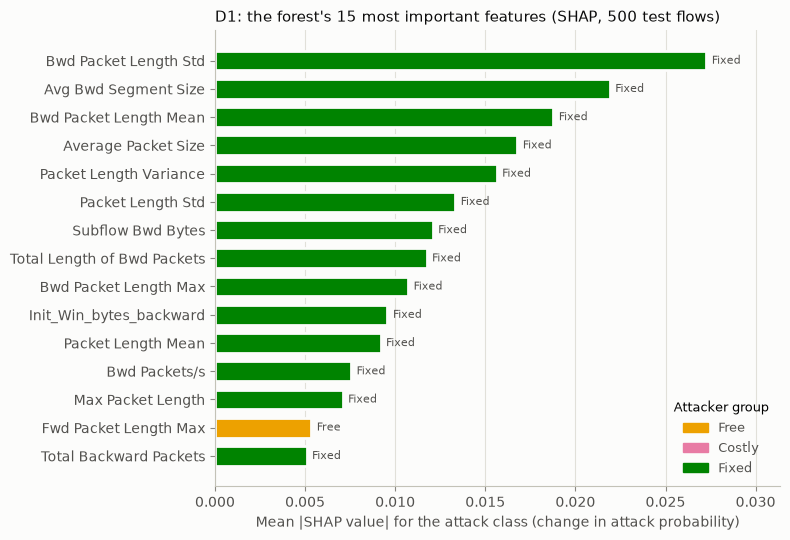

In [20]:
# STEP D1
# Figure: the SHAP top 15, bars coloured by attacker group, with the group also written next to
# each bar (two of the colours are light, so colour never carries the group alone).
GROUP_COLORS = {"Free": "#eda100", "Costly": "#e87ba4", "Fixed": "#008300"}
top15 = shap_rank.head(15)[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for side_ in ("top", "right"):
    ax.spines[side_].set_visible(False)
for side_ in ("left", "bottom"):
    ax.spines[side_].set_color(AXIS)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.barh(top15.index, top15.to_numpy(), color=[GROUP_COLORS[GROUP[f]] for f in top15.index],
        height=0.7, edgecolor=SURFACE, linewidth=2)
for y, f in enumerate(top15.index):
    ax.annotate(GROUP[f], xy=(top15[f], y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK_2)
ax.set_xlim(0, top15.max() * 1.15)
ax.tick_params(colors=MUTED, labelcolor=INK_2)
ax.set_xlabel("Mean |SHAP value| for the attack class (change in attack probability)", color=INK_2)
handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g]) for g in GROUP_COLORS]
ax.legend(handles, list(GROUP_COLORS), title="Attacker group", frameon=False, loc="lower right",
          labelcolor=INK_2, title_fontsize=9, fontsize=9)
ax.set_title("D1: the forest's 15 most important features (SHAP, 500 test flows)", color=INK,
             loc="left", fontsize=11)
fig.tight_layout()
fig.savefig("results/figures/D1_shap_bar.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP D1 -->
**What we found.** All ten of SHAP's most important features are **Fixed**, and Fixed features carry
77% of the total mean |SHAP| (Free 17%, Costly 5%). The overlap between SHAP's top ten and the
attacker's lists is **zero**: zero with the ten features the attack tried most, zero with the nine
features used in the successful evasions.

| SHAP rank | SHAP top 10 (all Fixed) | Attacker tried most (C3) | Group |
|---|---|---|---|
| 1 | Bwd Packet Length Std | Subflow Fwd Packets | Costly |
| 2 | Avg Bwd Segment Size | Total Length of Fwd Packets | Costly |
| 3 | Bwd Packet Length Mean | Fwd Packet Length Max | Free |
| 4 | Average Packet Size | Fwd Header Length | Free |
| 5 | Packet Length Variance | Total Fwd Packets | Costly |
| 6 | Packet Length Std | Subflow Fwd Bytes | Costly |
| 7 | Subflow Bwd Bytes | Fwd IAT Min | Free |
| 8 | Total Length of Bwd Packets | Flow IAT Min | Free |
| 9 | Bwd Packet Length Max | Active Std | Free |
| 10 | Init_Win_bytes_backward | Fwd IAT Std | Free |

**Check yourself: are the model's most important features ones the attacker can change?** No. The
forest decides mainly on the size of the **victim's replies** (`Bwd Packet Length …`, `Avg Bwd
Segment Size`) and on packet-size statistics that mix both directions. An attacker cannot forge
those, which is why the constrained attack in C2 stayed below 20% while the unconstrained attack,
which *could* edit the victim's replies (87% of its steps did), evaded everything. That is good news
for the defender, with two caveats:

- **The protection comes from the network, not the model.** If the attacker controls the other end
  too (a compromised server), the most important evidence becomes forgeable at once.
- **Twins can leak control.** `Subflow Bwd Bytes` and `Total Length of Bwd Packets` (SHAP ranks 7
  and 8) are twins (|corr| > 0.95) of the Costly `Total Fwd Packets`, `Subflow Fwd Packets` and
  `act_data_pkt_fwd`: in real traffic, more requests from the attacker usually mean more reply bytes
  from the victim. Our attack moves features one at a time, so it never exploits this. A real
  attacker might, so these two "Fixed" features are less safe than their label says.

**Check yourself: a feature used often by the attack but ranked low by SHAP, what could explain
that?** The two features behind all seven DDoS evasions, `Fwd IAT Min` and `Flow IAT Min`, rank only
41st and 58th of 68 in SHAP. Three reasons fit:

1. **SHAP ranks the average, the attacker exploits single flows.** Mean |SHAP| over 500 mostly benign
   flows says how much a feature matters *typically*. The attacker only needs a feature that matters
   for one flow already near the boundary, and for a few DDoS flows the minimum gap is exactly that.
2. **Big steps move a flow into regions the model rarely sees.** +4.8 s on the shortest gap is a
   value no ordinary flow has, so its contribution on the 500 explained flows says little about what
   happens there.
3. **The attack moves one feature but SHAP splits credit among twins.** Changes the attack tried
   often (forward counts) have Fixed twins that SHAP gives the credit to.

So a SHAP ranking is a poor guide to *where* an attacker will push: it describes what the model
relies on for typical flows, not where its decision boundary is thinnest.

<!-- STEP E1 -->
## Part E: Two defences

### Step E1: An ensemble

If one model is fooled by a change, a model with a different decision boundary may not be. We add a
**gradient boosting** model (200 trees of depth 4) and average the attack probabilities of three
models with very different boundaries: the random forest (deep trees, voting), gradient boosting
(shallow trees, built one after another) and logistic regression (one straight boundary).

**Training data.** Gradient boosting trains on one core and is slow on all 267,984 training rows, so
it is trained on a **stratified 100,000-row subsample** of the training set (seed 42), as the lab
allows. The forest and logistic regression are the ones from the setup, trained on the full set.

We compare the forest and the ensemble on clean data, 5% noise (B1), 10% missing values (B2) and the
constrained attack (C2). For the attack row we attack the **ensemble itself**, because a real attacker
probes the system that is actually deployed.

In [21]:
# STEP E1
from sklearn.ensemble import GradientBoostingClassifier

GB_PATH = MODEL_DIR / "gb.joblib"
gb = joblib.load(GB_PATH) if GB_PATH.is_file() else None
if gb is None or list(getattr(gb, "feature_names_in_", [])) != FEATURES:
    # Stratified on the attack type, like every split in this lab, so all attack families appear.
    gb_rows, _ = train_test_split(np.arange(len(X_train)), train_size=100_000,
                                  stratify=type_train, random_state=SEED)
    start = time.time()
    gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED)
    gb.fit(X_train.iloc[gb_rows], y_train.iloc[gb_rows])
    joblib.dump(gb, GB_PATH)
    print(f"gradient boosting trained on {len(gb_rows):,} rows in {time.time() - start:.0f} s")
else:
    print(f"gradient boosting loaded from {GB_PATH}")


class AvgEnsemble:
    """Average of the members' attack probabilities. Works with report() and greedy_attack()."""

    def __init__(self, models):
        self.models = models
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        return np.mean([m.predict_proba(X) for m in self.models], axis=0)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


ensemble = AvgEnsemble([rf, gb, logreg])

gradient boosting loaded from models/gb.joblib


In [22]:
# STEP E1
# Clean, 5% noise and 10% missing values: the same damaged test sets as in B1 and B2.
conditions = {
    "clean": X_test,
    "5% noise": add_noise(X_test, X_train, 0.05),
    "10% missing": add_missing(X_test, 0.10),
}
scored = {"forest": rf, "ensemble": ensemble, "gradient boosting": gb}
e1_rows = [{"condition": cond, "model": name, **report(model, Xc, y_test)}
           for cond, Xc in conditions.items() for name, model in scored.items()]
e1_scores = pd.DataFrame(e1_rows)
print(e1_scores.pivot(index="condition", columns="model", values="macro_f1")
      .loc[list(conditions)].round(4).to_string())
print()
print(e1_scores.pivot(index="condition", columns="model", values="recall")
      .loc[list(conditions)].round(4).to_string())

model        ensemble  forest  gradient boosting
condition                                       
clean          0.9965  0.9968             0.9962
5% noise       0.6205  0.5212             0.5007
10% missing    0.9725  0.9900             0.9421

model        ensemble  forest  gradient boosting
condition                                       
clean          0.9895  0.9923             0.9905
5% noise       0.1926  0.0633             0.1024
10% missing    0.9133  0.9681             0.8383


In [23]:
# STEP E1
# The constrained attack (C2) against the ensemble itself, on the same 50 flows.
start = time.time()
ens_rows, ens_adv = [], []
for pos in ATTACK_IDX:
    result = greedy_attack(ensemble, X_test.iloc[[pos]], constrained=True)
    ens_adv.append(result["x_adv"])
    ens_rows.append({"test_position": int(pos), "attack_type": type_test.iloc[pos],
                     "p_before": result["p_before"], "p_after": result["p_after"],
                     "evaded": result["p_after"] < 0.5,
                     "n_features_changed": len(set(result["changed"])),
                     "changed": ";".join(result["changed"])})
ensemble_attack = pd.DataFrame(ens_rows)
ensemble_adv = pd.concat(ens_adv)                   # the edited rows, in ATTACK_IDX order
print(f"attack on the ensemble: {time.time() - start:.0f} s")

already_missed = int((ensemble_attack["p_before"] < 0.5).sum())
print(f"Flows the ensemble already called benign before any change: {already_missed} of 50")
print(f"Ensemble p_before on the 50 flows: min {ensemble_attack['p_before'].min():.3f}, "
      f"mean {ensemble_attack['p_before'].mean():.3f}")

attack on the ensemble: 26 s
Flows the ensemble already called benign before any change: 0 of 50
Ensemble p_before on the 50 flows: min 0.701, mean 0.959


In [24]:
# STEP E1
forest_attack = attack_runs["constrained"]
attack_summary = pd.DataFrame({
    name: {"evaded (of 50)": int(df["evaded"].sum()),
           "already benign before the attack": int((df["p_before"] < 0.5).sum()),
           "mean p before": df["p_before"].mean(),
           "mean p after": df["p_after"].mean(),
           "mean features changed": df["n_features_changed"].mean()}
    for name, df in (("forest", forest_attack), ("ensemble", ensemble_attack))}).T

# The four-row comparison the lab asks for: macro-F1 and recall for clean / noise / missing,
# evaded-of-50 and mean probability after for the attack.
e1_table = pd.DataFrame({
    name: {
        **{f"{cond} macro-F1": e1_scores.query("condition == @cond and model == @name")["macro_f1"].item()
           for cond in conditions},
        **{f"{cond} recall": e1_scores.query("condition == @cond and model == @name")["recall"].item()
           for cond in conditions},
        "attack: evaded of 50": attack_summary.loc[name, "evaded (of 50)"],
        "attack: mean p after": attack_summary.loc[name, "mean p after"],
    } for name in ("forest", "ensemble")}).T
e1_table.to_csv("results/tables/E1_ensemble.csv", float_format="%.4f")
e1_scores.to_csv("results/tables/E1_scores_all.csv", index=False, float_format="%.4f")
ensemble_attack.to_csv("results/tables/E1_ensemble_attack_per_flow.csv", index=False, float_format="%.4f")
print(attack_summary.round(3).to_string())
e1_table.T.round(4)

          evaded (of 50)  already benign before the attack  mean p before  mean p after  mean features changed
forest               9.0                               0.0          1.000         0.731                   4.22
ensemble            11.0                               0.0          0.959         0.725                   3.94


,forest,ensemble
clean macro-F1,0.9968,0.9965
5% noise macro-F1,0.5212,0.6205
10% missing macro-F1,0.9900,0.9725
clean recall,0.9923,0.9895
5% noise recall,0.0633,0.1926
10% missing recall,0.9681,0.9133
attack: evaded of 50,9.0000,11.0000
attack: mean p after,0.7311,0.7246


In [25]:
# STEP E1
# Which members drive the ensemble under noise and under the attack?
members = {"forest": rf, "gradient boosting": gb, "logreg": logreg}
noisy = conditions["5% noise"]
attacks = y_test.to_numpy() == 1
print("Mean attack probability on real attacks, 5% noise:")
for name, m in members.items():
    print(f"  {name:<18} {m.predict_proba(noisy)[attacks, 1].mean():.3f}")

adv = ensemble_adv[ensemble_attack["evaded"].to_numpy()]
if len(adv):
    print("\nMember probabilities on the flows that evaded the ensemble:")
    member_p = pd.DataFrame({name: m.predict_proba(adv)[:, 1] for name, m in members.items()},
                            index=ensemble_attack.loc[ensemble_attack["evaded"], "attack_type"])
    print(member_p.round(3).to_string())
    before = pd.DataFrame({name: m.predict_proba(X_test.iloc[ATTACK_IDX[ensemble_attack["evaded"].to_numpy()]])[:, 1]
                           for name, m in members.items()})
    print("\nThe same flows before the attack (mean):", before.mean().round(3).to_dict())

Mean attack probability on real attacks, 5% noise:


  forest             0.357


  gradient boosting  0.122


  logreg             0.838

Member probabilities on the flows that evaded the ensemble:
               forest  gradient boosting  logreg
attack_type                                     
DoS GoldenEye   0.850              0.422   0.001
SSH-Patator     0.857              0.615   0.000
DDoS            0.737              0.538   0.054
DoS Hulk        0.683              0.790   0.017
DoS GoldenEye   0.833              0.422   0.001
DDoS            0.580              0.424   0.162
DDoS            0.740              0.648   0.062
DDoS            0.580              0.492   0.171
DDoS            0.573              0.416   0.166
DDoS            0.740              0.693   0.063
DDoS            0.637              0.481   0.329



The same flows before the attack (mean): {'forest': 1.0, 'gradient boosting': 0.987, 'logreg': 0.458}


In [26]:
# STEP E1
# Latency: how long does one decision take? An IDS answers per flow, often one at a time.
one_flow = X_test.iloc[[0]]
batch = X_test.iloc[:10_000]
latency = {}
for name, m in {"forest": rf, "gradient boosting": gb, "logreg": logreg, "ensemble": ensemble}.items():
    m.predict_proba(one_flow)                                    # warm-up
    t = time.perf_counter()
    for _ in range(20):
        m.predict_proba(one_flow)
    single_ms = (time.perf_counter() - t) / 20 * 1000
    t = time.perf_counter()
    m.predict_proba(batch)
    per_flow_us = (time.perf_counter() - t) / len(batch) * 1e6
    latency[name] = {"one flow (ms)": single_ms, "per flow in a batch of 10,000 (µs)": per_flow_us}
latency = pd.DataFrame(latency).T
latency.to_csv("results/tables/E1_latency.csv", float_format="%.3f")
latency.round(3)

,one flow (ms),"per flow in a batch of 10,000 (µs)"
forest,98.600,18.175
gradient boosting,2.715,7.216
logreg,3.119,4.024
ensemble,91.329,29.551


<!-- STEP E1 -->
**What we found.**

| | Forest | Ensemble (forest + GB + logreg) |
|---|---|---|
| Clean macro-F1 / recall | 0.997 / 0.992 | 0.997 / 0.990 |
| 5% noise macro-F1 / recall | 0.521 / 0.063 | **0.621 / 0.193** |
| 10% missing macro-F1 / recall | **0.990 / 0.968** | 0.973 / 0.913 |
| Constrained attack: evaded of 50 | **9** | 11 |
| Constrained attack: mean p after | 0.731 | 0.725 |

The ensemble is as good as the forest on clean data, a little better under noise, a little worse with
missing values, and **slightly easier to evade** (11 of 50 instead of 9). Gradient boosting was trained
on a stratified 100,000-row subsample of the training set (seed 42) to keep its training time at about
7 minutes; the forest and logistic regression use the full training set.

**Check yourself: did the ensemble help more against noise or against the attack, and why might those
differ?** Against noise, but only a little, and only thanks to logistic regression: under 5% noise the
forest gives real attacks an average probability of 0.36 and gradient boosting 0.12, while logistic
regression keeps 0.84 (B1 showed why: it reads features in units of their standard deviation). The
average of the three is pulled above 0.5 for some attacks, so recall rises from 0.06 to 0.19.

Against the attack the ensemble did *not* help, for the opposite reason. On the 11 flows that evaded
the ensemble, the forest alone still says "attack" (0.57–0.86), but logistic regression ends near 0
(at most 0.33). It was already unsure about exactly these flows before any change (mean 0.46, against
1.00 for the forest and 0.99 for gradient boosting), and a few extra packets and bytes push its linear
score the rest of the way. An average gives every member the same say, so the member that is easiest
to fool drags the ensemble under 0.5, and the attack automatically finds the flows where it is weak. The two kinds of damage differ in a basic way: noise is **random**, so independent errors
of different models partly cancel out in an average; the attacker is **adaptive**, probes the
ensemble itself and pushes on its weakest member. An ensemble only helps against an attacker if every
member is hard to fool, or if it combines members with a rule an attacker cannot exploit (for example
"alert if any member is confident").

**Check yourself: is running three models affordable in an IDS that answers in milliseconds?** On
this machine one flow takes about 90 ms with the forest alone and about the same with the ensemble
(the exact numbers vary by a few ms between runs); most of that is the overhead of spreading 300 trees
over 8 cores, not the models themselves. In batches of 10,000 flows the cost is about 20 µs per flow
for the forest and 30 µs for the ensemble (gradient boosting 8 µs, logistic regression 4 µs). So the
extra two models cost little; the forest is the expensive part. At line rate an IDS scores flows in
batches, where about 30 µs per flow is roughly 30,000 flows per second per machine, which is affordable for many networks but not for a busy backbone. Given that the
ensemble did not make the attack harder, the extra cost buys only the small gain under noise.